# Quarterly recommendation splits and a popularity baseline

Run `scripts/download_data.py`, then `scripts/make_splits.py` once before this notebook.
We learn from earlier **history → next-quarter outcomes** tasks, then predict the next quarter.
Initial training tasks cover 2003–2006, validation 2007–2010, and test 2011–2015; pre-2003 reviews remain history.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from remy.splits import RollingSplits, SPLIT_DIR
from remy.model.popularity import Popularity

splits = RollingSplits()
split = "val"  # Use "test" only after choosing and fixing model settings.
splits.windows.groupby("split", sort=False)[
    ["outcome_reviews", "positive_reviews", "positive_users"]
].sum().rename(columns={"positive_users": "positive_user_quarters"})

Matplotlib is building the font cache; this may take a moment.


,outcome_reviews,positive_reviews,positive_user_quarters
split,,,
train,138126,106422,19880
val,377717,279537,61814
test,134059,100846,29079


## The two API calls

`evaluation_quarters(split)` supplies the current history, available recipes, eligible users, and held-out outcomes.
`training_quarters(cutoff)` supplies only earlier tasks with completed outcome windows. A supervised model builds features from **each training task's own history**, with that task's outcomes as labels.

Popularity needs no supervised labels: it counts all past reviews, breaks ties by recipe ID, and excludes recipes the user already reviewed. The loop below still passes the training tasks to show the common model interface. Available recipes without reviews get score zero.

## Score, then roll forward

Positives are 5-star reviews in the following quarter, from users with at least three prior reviews of **any** rating, on available, previously unseen recipes. Users with no positive that quarter receive no ranking score.
We compute hit rate, recall, and NDCG at 10 and 100; average over users within each quarter, then over quarters equally.

In [2]:
def evaluate_quarter(model, quarter):
    """Score the same held-out positives for every method using this example."""
    positives = quarter.outcomes[quarter.outcomes["rating"] == 5]
    weights = 1 / np.log2(np.arange(2, 102))
    scores = []
    for user_id, rows in positives.groupby("user_id"):
        relevant = set(rows["recipe_id"])
        ranked = model.recommend(user_id, k=100)
        hits = np.array([recipe in relevant for recipe in ranked], dtype=float)
        metrics = {}
        for k in (10, 100):
            found = hits[:k]
            metrics[f"HR@{k}"] = float(found.any())
            metrics[f"Recall@{k}"] = found.sum() / len(relevant)
            ideal = weights[:min(k, len(relevant))].sum()
            metrics[f"NDCG@{k}"] = (found * weights[:len(found)]).sum() / ideal
        scores.append(metrics)
    if not scores:
        raise ValueError(f"No scorable users at {quarter.start.date()}")
    result = {
        "start": quarter.start,
        "eligible_users": len(quarter.users),
        "scored_users": len(scores),
        "positives": len(positives),
    }
    result.update(pd.DataFrame(scores).mean().to_dict())
    return result

In [3]:
rows = []
for quarter in splits.evaluation_quarters(split):
    model = Popularity()  # Fresh fit each quarter; keep the settings fixed.
    model.fit(
        quarter.history,
        recipes=quarter.recipes,
        training_quarters=splits.training_quarters(quarter.start),
    )
    # Current outcomes are used only for scoring, after the fit.
    rows.append(evaluate_quarter(model, quarter))

results = pd.DataFrame(rows)
results.to_csv(SPLIT_DIR / f"popularity_{split}.csv", index=False)
results.filter(like="@").mean().to_frame("Mean across quarters").round(4)

,Mean across quarters
HR@10,0.0398
Recall@10,0.0157
NDCG@10,0.0096
HR@100,0.1604
Recall@100,0.0703
NDCG@100,0.0227


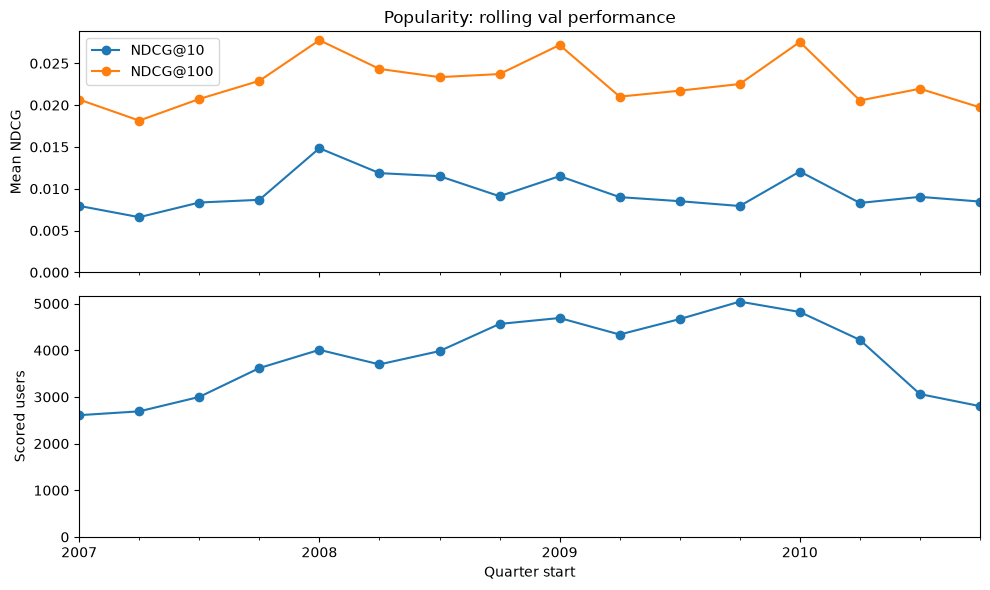

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
results.plot(x="start", y=["NDCG@10", "NDCG@100"], marker="o", ax=axes[0])
axes[0].set(title=f"Popularity: rolling {split} performance", ylabel="Mean NDCG")
axes[0].set_ylim(bottom=0)
results.plot(x="start", y="scored_users", marker="o", legend=False, ax=axes[1])
axes[1].set(ylabel="Scored users", xlabel="Quarter start")
axes[1].set_ylim(bottom=0)
fig.tight_layout()
plt.show()

The curves describe active, eligible users, not every visitor. The second chart shows how the scored population changes; repeated users across quarters are not independent samples.

Below are the most-reviewed recipes at the **last checkpoint**, using only history available then. These are the common ranking before each user's seen recipes are removed.

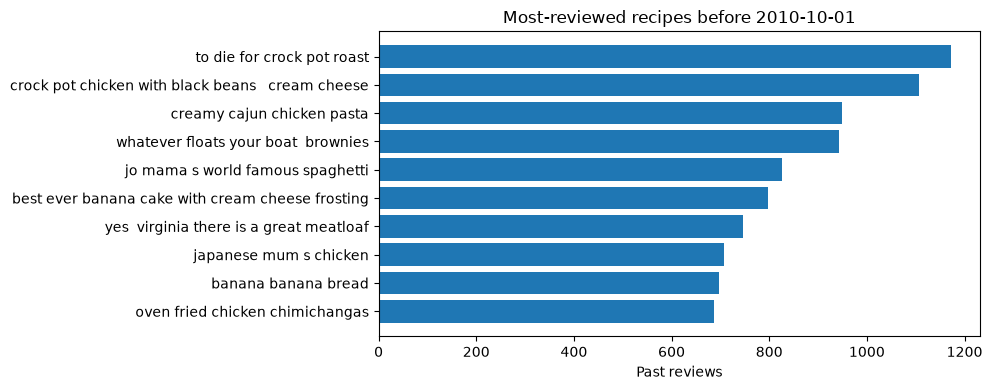

In [5]:
top = model.scores_.head(10).sort_values()
names = quarter.recipes.set_index("id")["name"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(names.reindex(top.index), top.values)
ax.set(title=f"Most-reviewed recipes before {quarter.start.date()}", xlabel="Past reviews")
fig.tight_layout()
plt.show()